# Exploratory Data Analysis

This notebook explores weather, air quality, temporal patterns, geographic variation, anomalies, and several applied indicators using `weather_cleaned.csv`.

## Analysis flow

1. Setup and data readiness  
2. Dataset overview  
3. Weather distributions and relationships  
4. Temporal and condition patterns  
5. Air quality analysis  
6. Geographic analysis  
7. Anomaly detection  
8. Applied analyses  
9. Limitations and conclusions  

> **Scope note:** The repository contains daily observations recorded at varying local update times. It is suitable for broad daily, seasonal, and geographic comparisons, but it is not a complete hourly time series for every location.

## 1. Setup and Data Readiness

In [6]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [7]:
def find_project_file(filename: str) -> Path:
    for folder in [Path.cwd(), *Path.cwd().parents]:
        candidate = folder / filename
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {filename}. Place it in the project root "
        "or in the same folder as this notebook."
    )

data_path = find_project_file("weather_cleaned.csv")
df = pd.read_csv(data_path, parse_dates=["last_updated"])

print("Loaded:", data_path)
print("Shape:", df.shape)
print("Date range:", df["last_updated"].min(), "to", df["last_updated"].max())
df.head()

Loaded: c:\Users\Aeiman Imtiaz\Desktop\Internship task\datascience\weather_cleaned.csv
Shape: (153586, 38)
Date range: 2024-05-16 02:45:00 to 2026-07-18 19:00:00


,country,location_name,latitude,longitude,timezone,last_updated,temperature_celsius,condition_text,wind_kph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,year,month,month_name,day_of_week,hour
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,2024-05-16 13:15:00,26.6,Partly Cloudy,13.3,338.0,NNW,1012.0,0.0,24.0,30.0,25.3,10.0,7.0,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,13
1,Albania,Tirana,41.33,19.82,Europe/Tirane,2024-05-16 10:45:00,19.0,Partly cloudy,11.2,320.0,NW,1012.0,0.1,94.0,75.0,19.0,10.0,5.0,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,2024-05-16 09:45:00,23.0,Sunny,15.1,280.0,W,1011.0,0.0,29.0,0.0,24.6,10.0,5.0,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,2024-05-16 10:45:00,6.3,Light drizzle,11.9,215.0,SW,1007.0,0.3,61.0,100.0,3.8,2.0,2.0,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,10
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,2024-05-16 09:45:00,26.0,Partly cloudy,13.0,150.0,SSE,1011.0,0.0,89.0,50.0,28.7,10.0,8.0,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55.0,2024,5,May,Thursday,9


### 1.1 Derived fields used in the analysis

In [8]:
month_order = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]
weekday_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

# Re-create calendar fields only if they are not already present.
if "year" not in df.columns:
    df["year"] = df["last_updated"].dt.year
if "month" not in df.columns:
    df["month"] = df["last_updated"].dt.month
if "month_name" not in df.columns:
    df["month_name"] = df["last_updated"].dt.month_name()
if "day_of_week" not in df.columns:
    df["day_of_week"] = df["last_updated"].dt.day_name()

df["year_month"] = df["last_updated"].dt.to_period("M")
df["recorded_hour"] = df["last_updated"].dt.hour

df["month_name"] = pd.Categorical(
    df["month_name"], categories=month_order, ordered=True
)
df["day_of_week"] = pd.Categorical(
    df["day_of_week"], categories=weekday_order, ordered=True
)

### 1.2 Quality checks

In [9]:
overview = pd.DataFrame(
    {
        "Metric": [
            "Observations",
            "Columns",
            "Countries",
            "Country-location pairs",
            "Start date",
            "End date",
            "Missing cells",
            "Exact duplicate rows",
            "Duplicate country-location-date records",
        ],
        "Value": [
            len(df),
            df.shape[1],
            df["country"].nunique(),
            df[["country", "location_name"]].drop_duplicates().shape[0],
            df["last_updated"].min(),
            df["last_updated"].max(),
            int(df.isna().sum().sum()),
            int(df.duplicated().sum()),
            int(
                df.duplicated(
                    subset=["country", "location_name", "last_updated"],
                    keep=False,
                ).sum()
            ),
        ],
    }
)
overview

,Metric,Value
0,Observations,153586
1,Columns,40
2,Countries,186
3,Country-location pairs,219
4,Start date,2024-05-16 02:45:00
5,End date,2026-07-18 19:00:00
6,Missing cells,10
7,Exact duplicate rows,0
8,Duplicate country-location-date records,2


In [10]:
missing_summary = (
    pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_percentage": (df.isna().mean() * 100).round(4),
        }
    )
    .query("missing_count > 0")
    .sort_values("missing_percentage", ascending=False)
)

missing_summary

,missing_count,missing_percentage
pressure_mb,2,0.0013
air_quality_PM10,2,0.0013
wind_kph,1,0.0007
temperature_celsius,1,0.0007
feels_like_celsius,1,0.0007
gust_kph,1,0.0007
air_quality_Carbon_Monoxide,1,0.0007
air_quality_Sulphur_dioxide,1,0.0007


The preprocessing notebook already handled known invalid values. Missing measurements are retained and each analysis below uses the available values for the variables it needs rather than deleting otherwise useful rows.

## 2. Dataset Overview

In [11]:
location_coverage = (
    df.groupby(["country", "location_name"])
    .agg(
        observations=("last_updated", "size"),
        first_date=("last_updated", "min"),
        last_date=("last_updated", "max"),
        months_covered=("year_month", "nunique"),
    )
    .reset_index()
)

display(location_coverage["observations"].describe().to_frame().T.round(1))
display(location_coverage.sort_values("observations").head(15))

,count,mean,std,min,25%,50%,75%,max
observations,219.0,701.3,212.8,30.0,787.0,789.0,791.0,792.0


,country,location_name,observations,first_date,last_date,months_covered
34,Cameroon,Aba,30,2026-06-05 07:15:00,2026-07-18 06:45:00,2
145,Palau,Aakip,32,2026-06-06 15:00:00,2026-07-18 14:45:00,2
119,Maldives,Felidhoo,34,2024-05-16 13:45:00,2024-06-17 19:00:00,2
84,Iceland,Grindavik,36,2024-05-16 08:45:00,2024-06-19 13:45:00,2
153,Paraguay,Sartorio,36,2026-02-20 04:00:00,2026-07-18 03:00:00,5
97,Jamaica,Norman Gardens,36,2024-05-16 03:45:00,2024-06-19 08:45:00,2
160,Russia,Chi-Chi-Erh,41,2025-12-21 14:00:00,2026-04-18 13:30:00,5
215,Vietnam,S. Manian,42,2025-12-28 14:15:00,2026-04-27 13:30:00,5
83,Iceland,Abaer,44,2026-06-05 06:15:00,2026-07-18 05:45:00,2
45,Costa Rica,San Andres,44,2026-06-05 00:15:00,2026-07-17 23:45:00,2


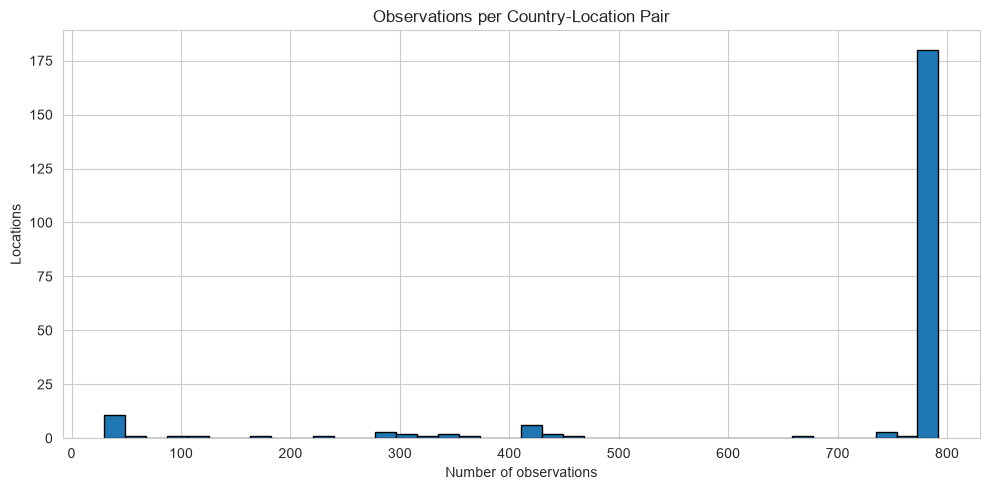

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(location_coverage["observations"], bins=40, edgecolor="black")
ax.set_title("Observations per Country-Location Pair")
ax.set_xlabel("Number of observations")
ax.set_ylabel("Locations")
plt.tight_layout()
plt.show()

Coverage is not identical across locations. Country and city rankings should therefore be interpreted as summaries of the sampled locations and dates rather than complete national climate statistics.

## 3. Weather Distributions and Relationships

### 3.1 Descriptive statistics

In [13]:
weather_columns = [
    "temperature_celsius",
    "feels_like_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "gust_kph",
    "precip_mm",
    "visibility_km",
    "cloud",
    "uv_index",
]

descriptive_stats = df[weather_columns].describe().T
descriptive_stats["median"] = df[weather_columns].median()
descriptive_stats["skewness"] = df[weather_columns].skew()

display(
    descriptive_stats[
        ["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skewness"]
    ].round(2)
)

,count,mean,median,std,min,25%,50%,75%,max,skewness
temperature_celsius,153585.0,21.36,23.7,9.48,-29.8,16.1,23.7,27.90,49.20,-0.83
feels_like_celsius,153585.0,22.14,25.0,11.38,-36.7,15.9,25.0,29.80,51.20,-0.78
humidity,153586.0,66.96,72.0,23.63,2.0,52.0,72.0,86.00,100.00,-0.67
pressure_mb,153584.0,1014.04,1014.0,6.89,947.0,1010.0,1014.0,1018.00,1080.00,0.04
wind_kph,153585.0,12.76,10.8,8.37,3.6,6.1,10.8,17.60,272.20,1.62
gust_kph,153585.0,18.07,15.1,11.22,3.6,10.0,15.1,24.00,279.40,1.48
precip_mm,153586.0,0.13,0.0,0.56,0.0,0.0,0.0,0.02,42.24,18.16
visibility_km,153586.0,9.51,10.0,2.68,0.0,10.0,10.0,10.00,32.00,1.05
cloud,153586.0,39.46,26.0,34.08,0.0,0.0,26.0,75.00,100.00,0.26
uv_index,153586.0,3.19,1.6,3.51,0.0,0.0,1.6,6.00,16.30,0.96


### 3.2 Distribution shapes

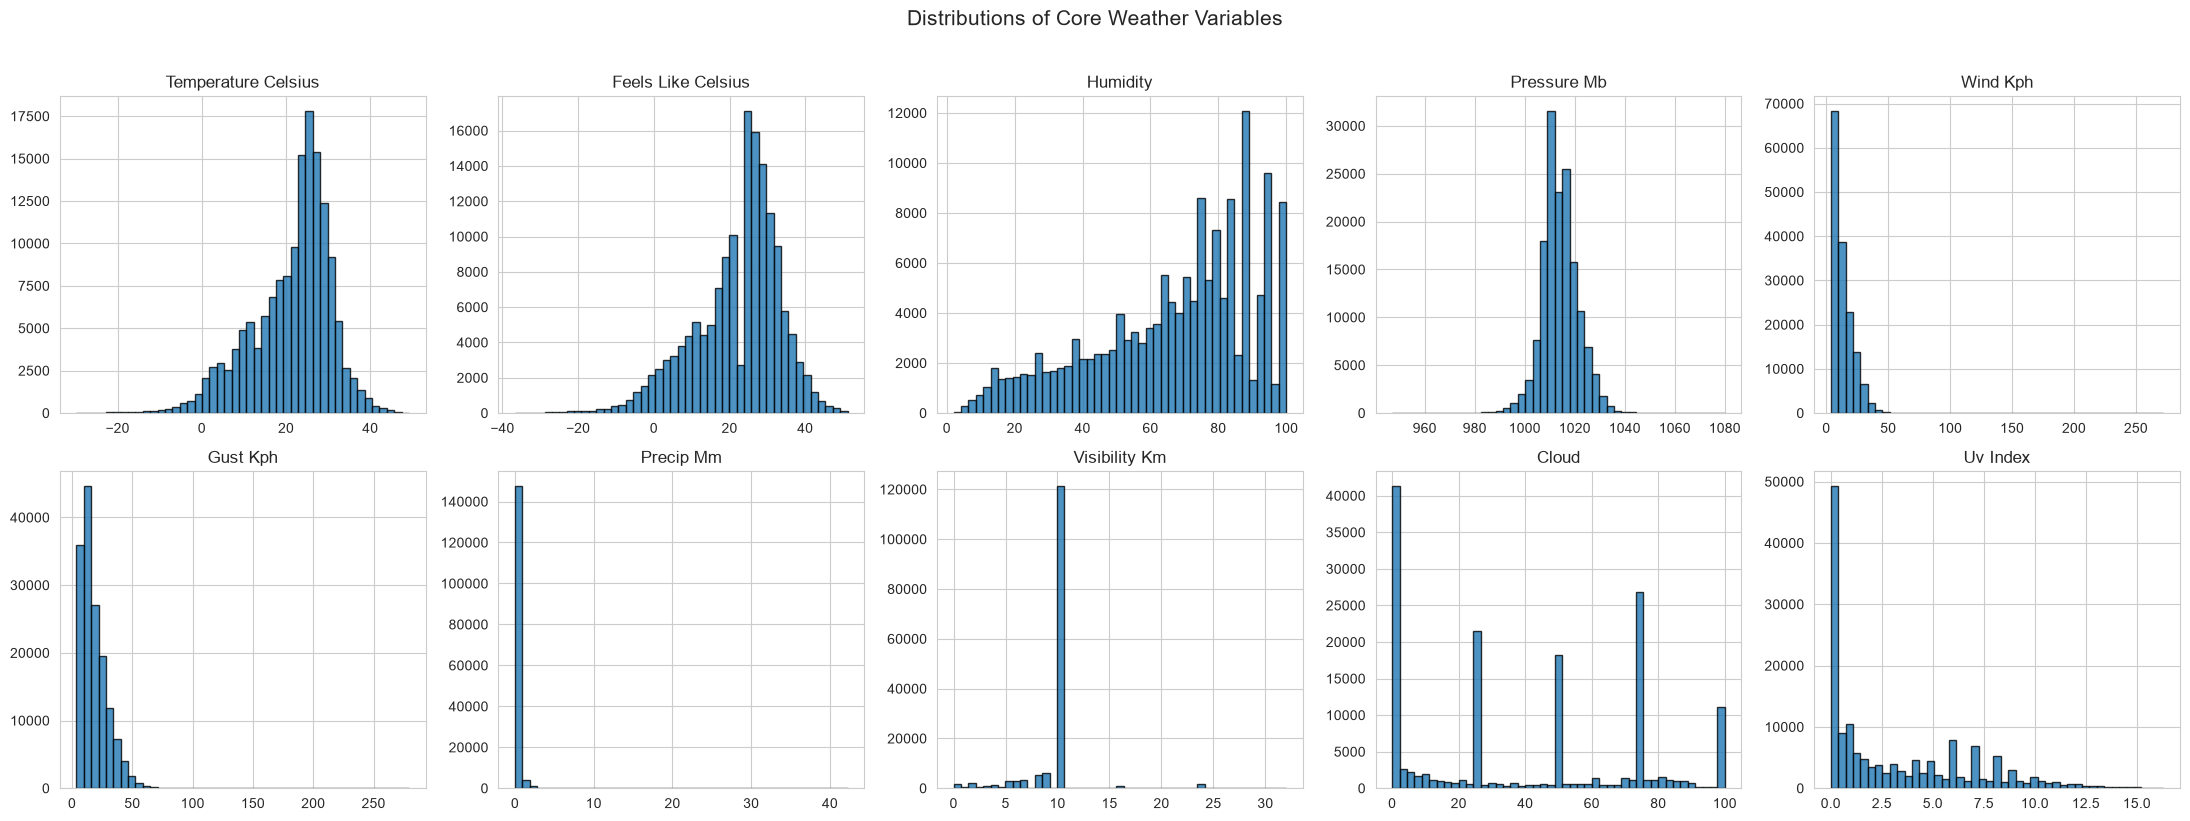

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(22, 8))

for ax, column in zip(axes.flat, weather_columns):
    ax.hist(df[column].dropna(), bins=45, edgecolor="black", alpha=0.8)
    ax.set_title(column.replace("_", " ").title())
    ax.set_xlabel("")

plt.suptitle("Distributions of Core Weather Variables", y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

Temperature is comparatively smooth, while wind, precipitation, and several other variables are right-skewed. For skewed variables, medians and robust methods are often more informative than means alone.

### 3.3 Correlation structure

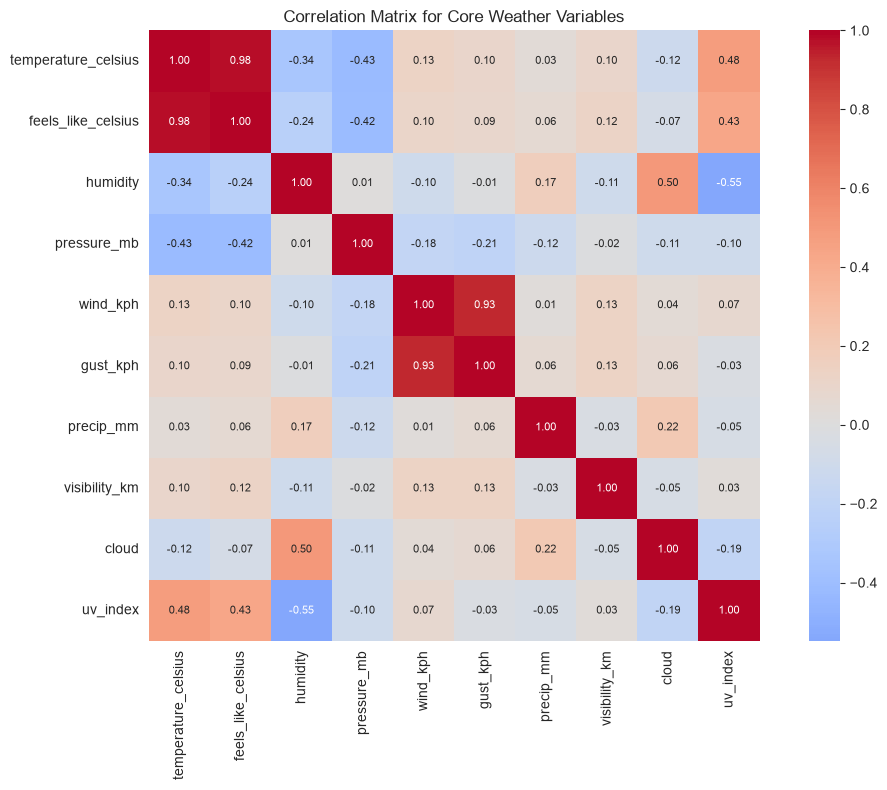

In [15]:
weather_corr = df[weather_columns].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(
    weather_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    annot_kws={"size": 8},
)
plt.title("Correlation Matrix for Core Weather Variables")
plt.tight_layout()
plt.show()

In [16]:
correlation_pairs = (
    weather_corr.where(
        np.triu(np.ones(weather_corr.shape), k=1).astype(bool)
    )
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)

correlation_pairs["absolute_correlation"] = correlation_pairs["correlation"].abs()

display(
    correlation_pairs
    .sort_values("absolute_correlation", ascending=False)
    .head(12)
    .drop(columns="absolute_correlation")
    .round(3)
)

,variable_1,variable_2,correlation
1,temperature_celsius,feels_like_celsius,0.980
45,wind_kph,gust_kph,0.932
29,humidity,uv_index,-0.549
28,humidity,cloud,0.503
9,temperature_celsius,uv_index,0.485
19,feels_like_celsius,uv_index,0.435
3,temperature_celsius,pressure_mb,-0.425
13,feels_like_celsius,pressure_mb,-0.422
2,temperature_celsius,humidity,-0.340
12,feels_like_celsius,humidity,-0.244


The strongest relationships are physically intuitive: temperature closely tracks feels-like temperature, cloud cover is associated with lower visibility, and precipitation is related to cloud and humidity. Correlation describes association, not causation.

## 4. Temporal and Weather-Condition Patterns

### 4.1 Observation coverage over time

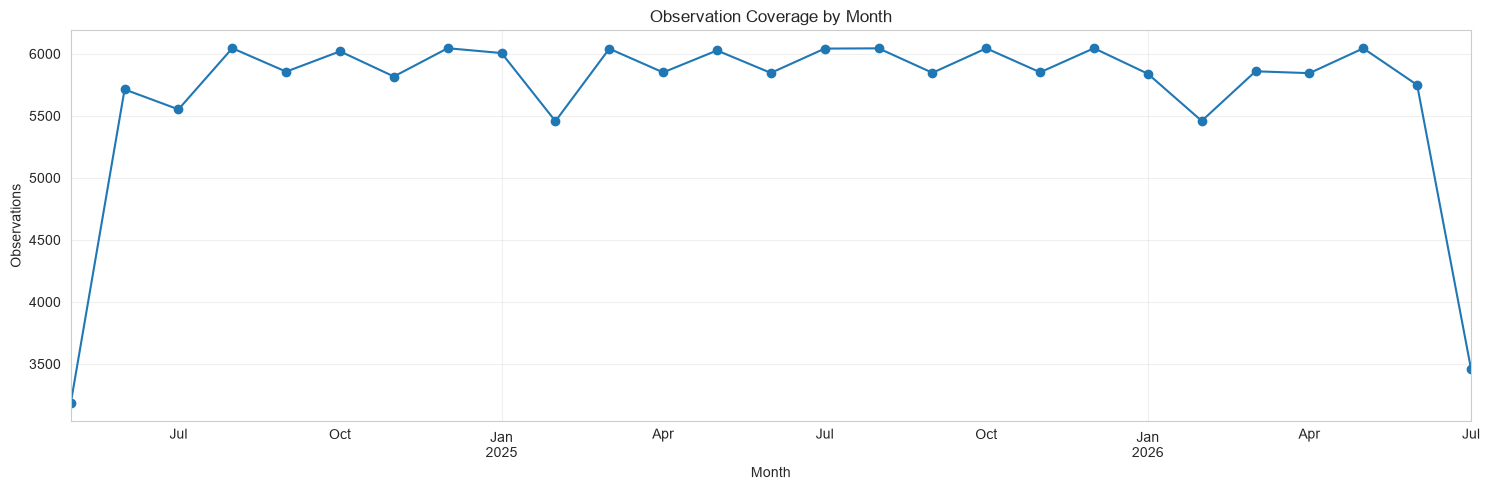

In [17]:
monthly_coverage = df.groupby("year_month").size()

fig, ax = plt.subplots(figsize=(15, 5))
monthly_coverage.plot(ax=ax, marker="o")
ax.set_title("Observation Coverage by Month")
ax.set_xlabel("Month")
ax.set_ylabel("Observations")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Monthly weather patterns

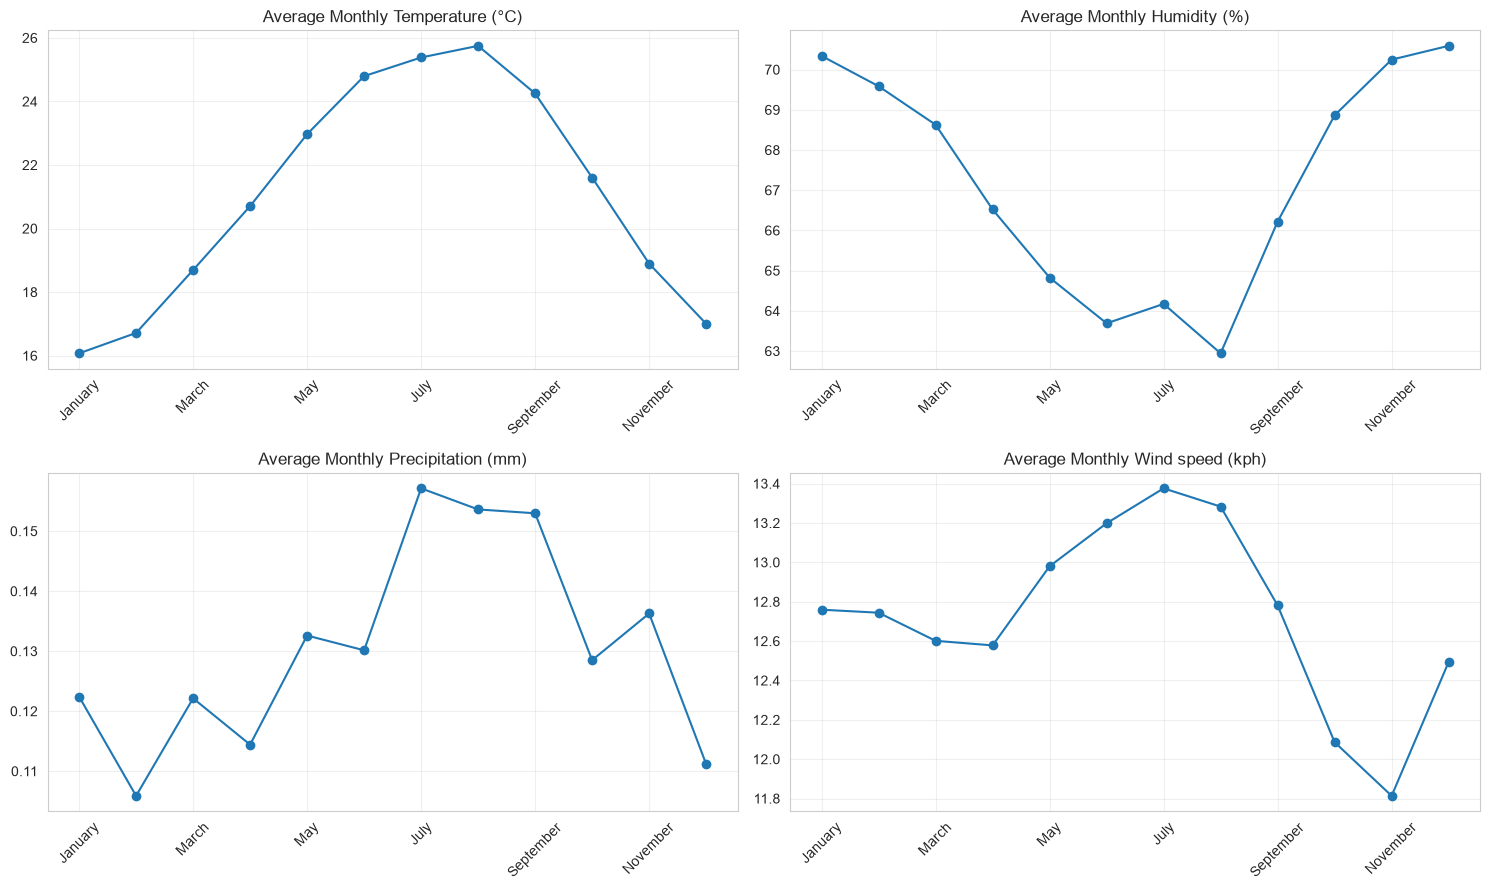

In [18]:
monthly_weather = (
    df.groupby("month_name", observed=False)[
        ["temperature_celsius", "humidity", "precip_mm", "wind_kph"]
    ]
    .mean()
    .reindex(month_order)
)

fig, axes = plt.subplots(2, 2, figsize=(15, 9))
labels = {
    "temperature_celsius": "Temperature (°C)",
    "humidity": "Humidity (%)",
    "precip_mm": "Precipitation (mm)",
    "wind_kph": "Wind speed (kph)",
}

for ax, column in zip(axes.flat, monthly_weather.columns):
    monthly_weather[column].plot(ax=ax, marker="o")
    ax.set_title(f"Average Monthly {labels[column]}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

The global monthly averages show clear seasonality, but the pattern is influenced by geographic coverage and mixes both hemispheres. It should be described as a dataset-wide seasonal pattern rather than a universal climate cycle.

### 4.3 Day-of-week sanity check

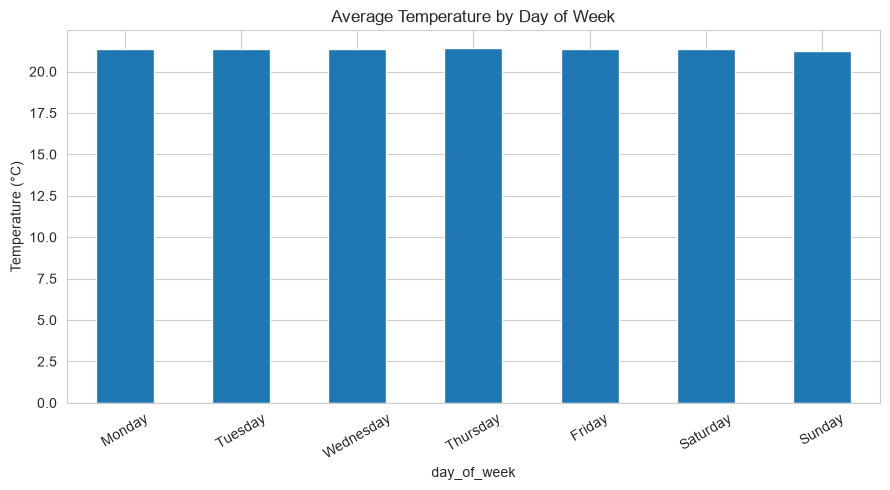

Maximum difference across weekdays: 0.146 °C


In [19]:
weekday_temperature = (
    df.groupby("day_of_week", observed=False)["temperature_celsius"]
    .mean()
    .reindex(weekday_order)
)

fig, ax = plt.subplots(figsize=(9, 5))
weekday_temperature.plot(kind="bar", ax=ax)
ax.set_title("Average Temperature by Day of Week")
ax.set_ylabel("Temperature (°C)")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

print(
    "Maximum difference across weekdays:",
    round(weekday_temperature.max() - weekday_temperature.min(), 3),
    "°C",
)

This is primarily a data-quality check. Weather should not show a meaningful weekday effect, and any very small differences are more likely due to sampling variation.

### 4.4 Daylight duration by month

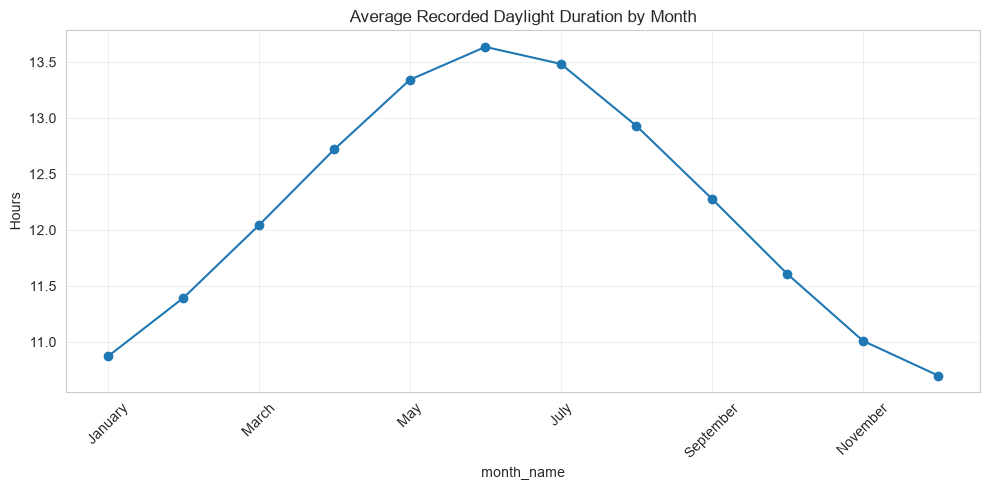

In [20]:
date_text = df["last_updated"].dt.strftime("%Y-%m-%d")
sunrise_dt = pd.to_datetime(
    date_text + " " + df["sunrise"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce",
)
sunset_dt = pd.to_datetime(
    date_text + " " + df["sunset"],
    format="%Y-%m-%d %I:%M %p",
    errors="coerce",
)

daylight_hours = (sunset_dt - sunrise_dt).dt.total_seconds() / 3600
daylight_hours = daylight_hours.where(daylight_hours >= 0, daylight_hours + 24)

daylight_by_month = (
    daylight_hours.groupby(df["month_name"], observed=False)
    .mean()
    .reindex(month_order)
)

fig, ax = plt.subplots(figsize=(10, 5))
daylight_by_month.plot(ax=ax, marker="o")
ax.set_title("Average Recorded Daylight Duration by Month")
ax.set_ylabel("Hours")
ax.tick_params(axis="x", rotation=45)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 4.5 Weather-condition categories

In [21]:
condition_text = df["condition_text"].fillna("").str.lower()

category_rules = [
    condition_text.str.contains("thunder|thundery", regex=True),
    condition_text.str.contains("snow|sleet|freezing|blizzard", regex=True),
    condition_text.str.contains("rain|drizzle|shower", regex=True),
    condition_text.str.contains("fog|mist", regex=True),
    condition_text.str.contains("dust|sand", regex=True),
    condition_text.str.contains("cloud|overcast", regex=True),
    condition_text.str.contains("sunny|clear", regex=True),
]
category_names = [
    "Thunderstorm",
    "Snow / Ice",
    "Rain",
    "Fog / Mist",
    "Dust / Sand",
    "Cloudy / Overcast",
    "Clear / Sunny",
]

df["weather_category"] = np.select(
    category_rules,
    category_names,
    default="Other",
)

,observations,mean_temperature,mean_visibility,mean_precipitation
weather_category,,,,
Cloudy / Overcast,62813,21.36,10.18,0.11
Clear / Sunny,53259,22.24,9.88,0.00
Rain,24707,21.78,9.20,0.44
Fog / Mist,8224,17.44,4.08,0.03
Thunderstorm,2733,25.12,8.59,0.47
Snow / Ice,1488,-2.89,5.86,0.26
Other,244,18.27,7.39,0.00
Dust / Sand,118,34.42,6.71,0.00


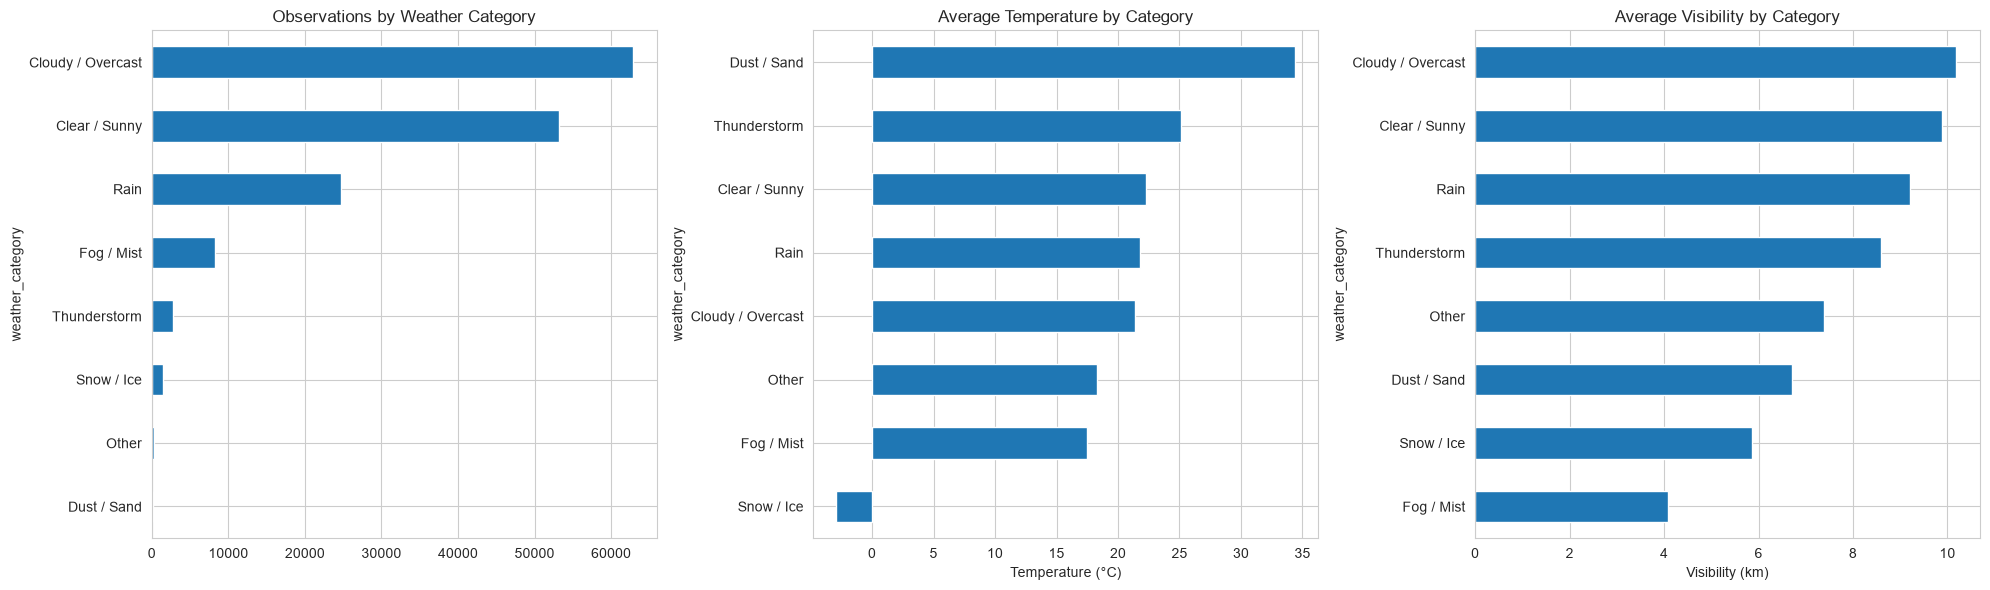

In [22]:
condition_summary = (
    df.groupby("weather_category")
    .agg(
        observations=("weather_category", "size"),
        mean_temperature=("temperature_celsius", "mean"),
        mean_visibility=("visibility_km", "mean"),
        mean_precipitation=("precip_mm", "mean"),
    )
    .sort_values("observations", ascending=False)
)

display(condition_summary.round(2))

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

condition_summary["observations"].sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Observations by Weather Category")

condition_summary["mean_temperature"].sort_values().plot(kind="barh", ax=axes[1])
axes[1].set_title("Average Temperature by Category")
axes[1].set_xlabel("Temperature (°C)")

condition_summary["mean_visibility"].sort_values().plot(kind="barh", ax=axes[2])
axes[2].set_title("Average Visibility by Category")
axes[2].set_xlabel("Visibility (km)")

plt.tight_layout()
plt.show()

## 5. Air Quality Analysis

### 5.1 Pollutant distributions

In [24]:
air_quality_columns = [
    "air_quality_Carbon_Monoxide",
    "air_quality_Ozone",
    "air_quality_Nitrogen_dioxide",
    "air_quality_Sulphur_dioxide",
    "air_quality_PM2.5",
    "air_quality_PM10",
]

df[air_quality_columns].describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
air_quality_Carbon_Monoxide,153585.0,433.91,722.51,53.85,185.30,277.50,436.85,38879.40
air_quality_Ozone,153586.0,57.78,30.74,0.00,38.00,55.00,73.00,480.70
air_quality_Nitrogen_dioxide,153586.0,14.41,22.82,0.00,1.75,5.55,16.46,427.70
air_quality_Sulphur_dioxide,153585.0,9.94,22.13,0.00,1.11,2.40,7.77,521.33
air_quality_PM2.5,153586.0,23.33,35.45,0.17,6.90,13.55,26.64,1614.10
air_quality_PM10,153584.0,46.88,144.04,0.17,9.70,19.24,40.10,6037.29


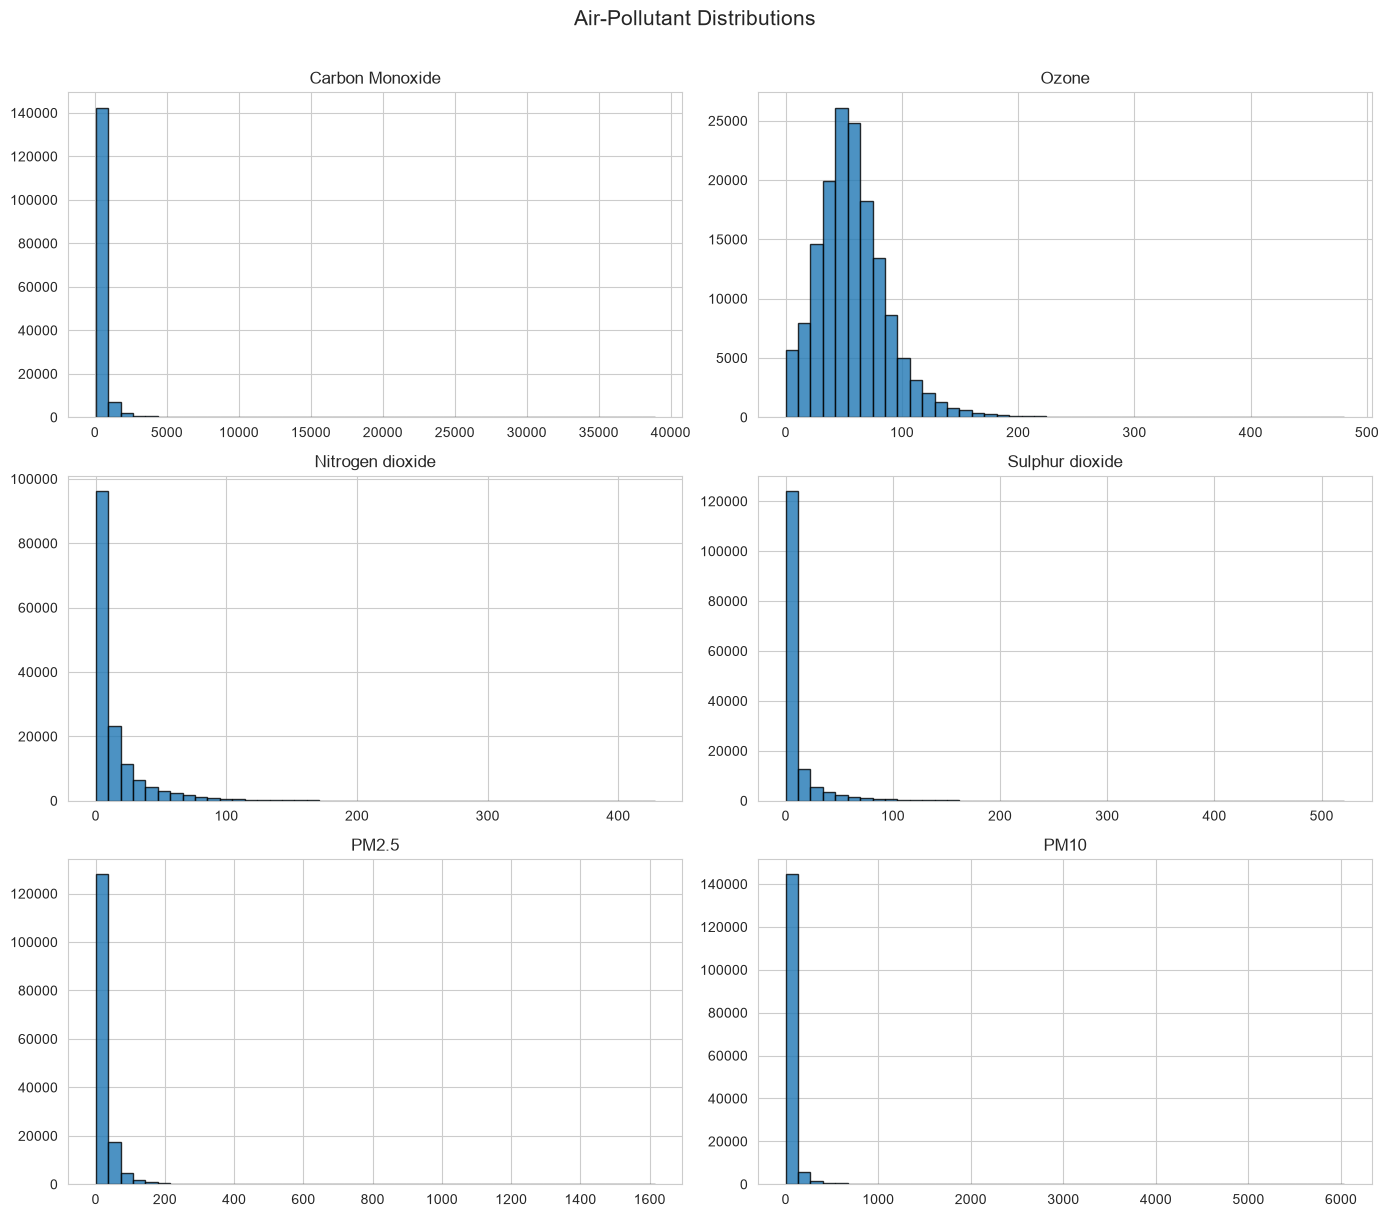

In [25]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for ax, column in zip(axes.flat, air_quality_columns):
    ax.hist(df[column].dropna(), bins=45, edgecolor="black", alpha=0.8)
    ax.set_title(column.replace("air_quality_", "").replace("_", " "))
    ax.set_xlabel("")

plt.suptitle("Air-Pollutant Distributions", y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

Pollutant concentrations are strongly right-skewed. Most observations are relatively low, with a smaller number of high-pollution episodes.

### 5.2 Weather and air-quality relationships

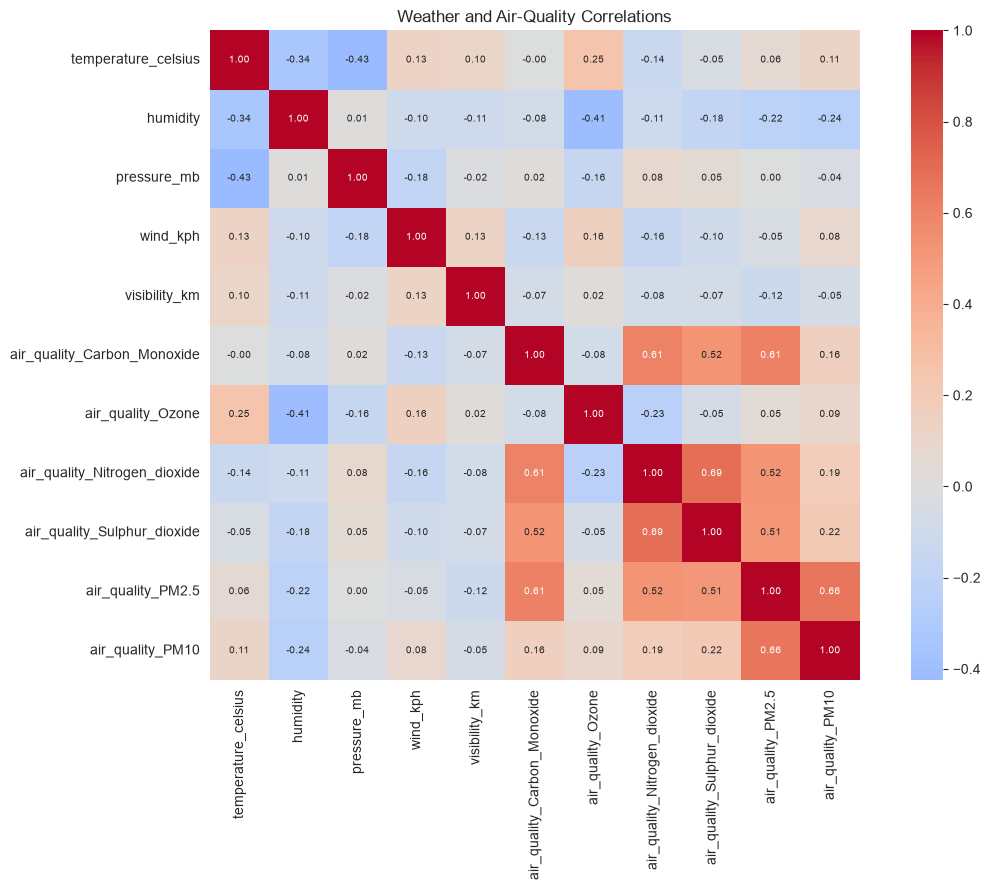

In [26]:
weather_air_columns = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "visibility_km",
] + air_quality_columns

air_weather_corr = df[weather_air_columns].corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    air_weather_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    annot_kws={"size": 7},
)
plt.title("Weather and Air-Quality Correlations")
plt.tight_layout()
plt.show()

Several pollutants move together, while their relationships with weather variables are generally weaker. These associations may reflect a mixture of emissions, atmospheric conditions, seasonality, and geographic composition.

### 5.3 Seasonal air-quality patterns

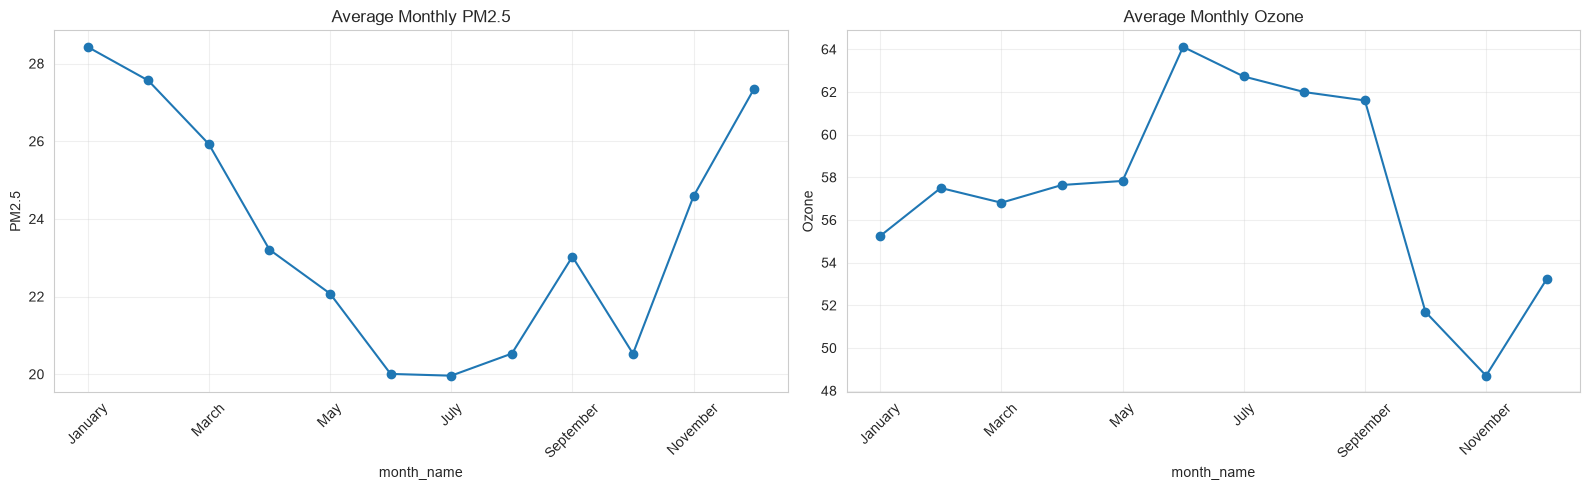

In [27]:
monthly_air = (
    df.groupby("month_name", observed=False)[
        ["air_quality_PM2.5", "air_quality_Ozone"]
    ]
    .mean()
    .reindex(month_order)
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

monthly_air["air_quality_PM2.5"].plot(ax=axes[0], marker="o")
axes[0].set_title("Average Monthly PM2.5")
axes[0].set_ylabel("PM2.5")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(alpha=0.3)

monthly_air["air_quality_Ozone"].plot(ax=axes[1], marker="o")
axes[1].set_title("Average Monthly Ozone")
axes[1].set_ylabel("Ozone")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

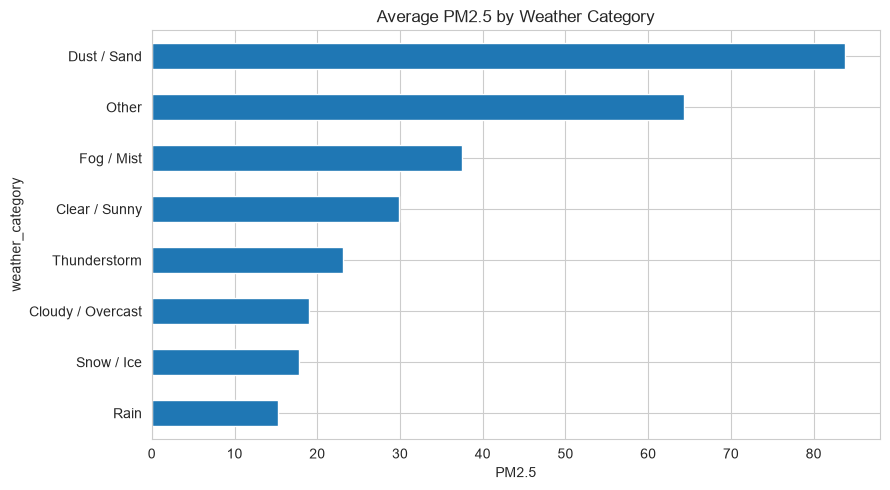

In [28]:
pm25_by_condition = (
    df.groupby("weather_category")["air_quality_PM2.5"]
    .mean()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))
pm25_by_condition.plot(kind="barh", ax=ax)
ax.set_title("Average PM2.5 by Weather Category")
ax.set_xlabel("PM2.5")
plt.tight_layout()
plt.show()

## 6. Geographic Analysis

### 6.1 Latitude and temperature

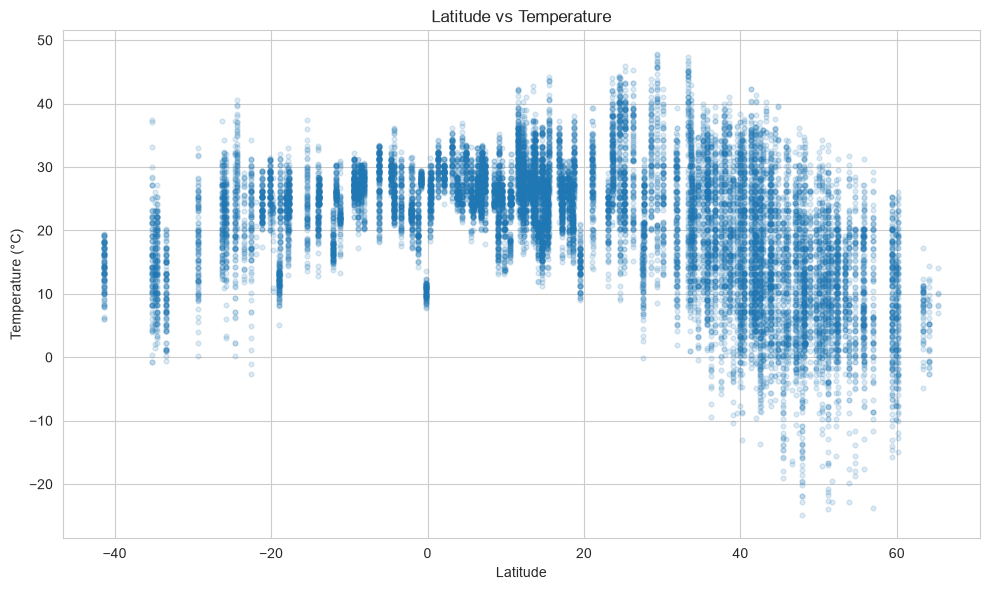

Correlation between absolute latitude and temperature: -0.558


In [29]:
geo_rows = df.dropna(
    subset=["latitude", "temperature_celsius"]
)
geo_sample = geo_rows.sample(
    min(20000, len(geo_rows)),
    random_state=RANDOM_STATE,
)

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(
    geo_sample["latitude"],
    geo_sample["temperature_celsius"],
    alpha=0.15,
    s=12,
)
ax.set_title("Latitude vs Temperature")
ax.set_xlabel("Latitude")
ax.set_ylabel("Temperature (°C)")
plt.tight_layout()
plt.show()

latitude_correlation = df["latitude"].abs().corr(df["temperature_celsius"])
print("Correlation between absolute latitude and temperature:", round(latitude_correlation, 3))

Temperatures generally decline with distance from the equator, although altitude, season, ocean influence, and local geography create substantial variation.

### 6.2 Temperature rankings for sampled locations

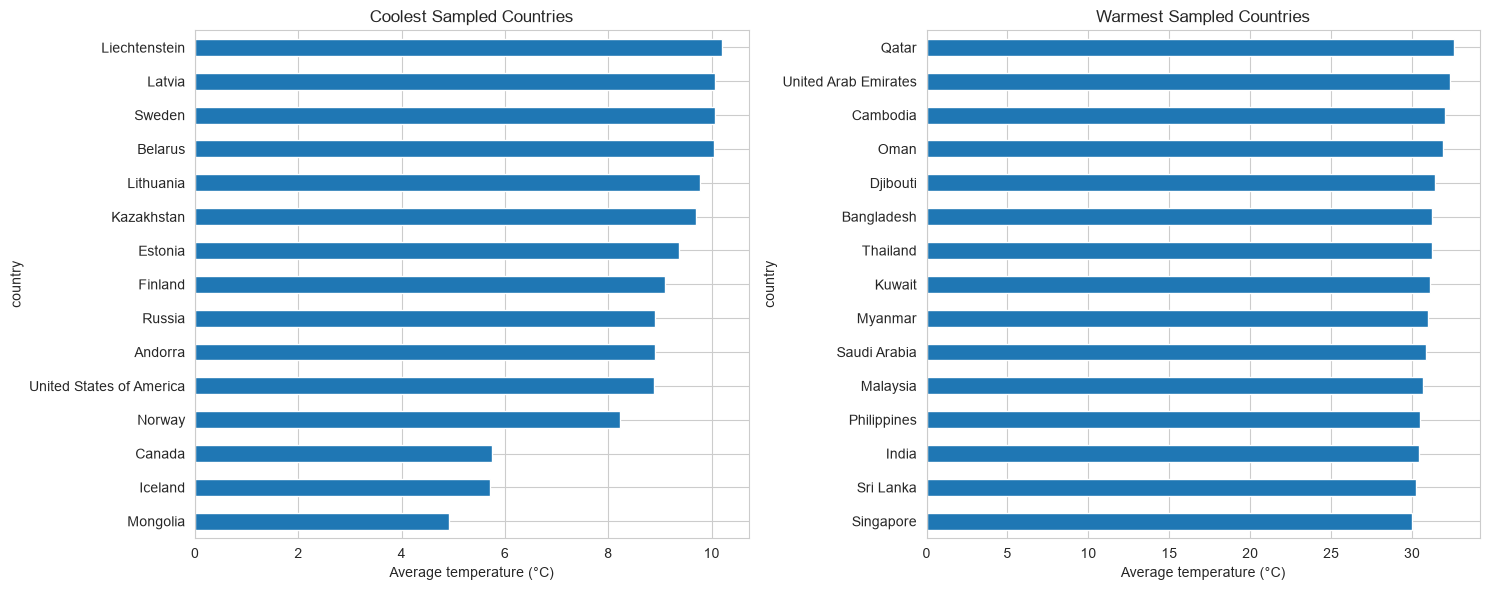

In [30]:
country_temperature = (
    df.groupby("country")["temperature_celsius"]
    .mean()
    .sort_values()
)

location_temperature = (
    df.assign(
        location_label=df["location_name"] + ", " + df["country"]
    )
    .groupby("location_label")["temperature_celsius"]
    .mean()
    .sort_values()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
country_temperature.head(15).plot(kind="barh", ax=axes[0])
axes[0].set_title("Coolest Sampled Countries")
axes[0].set_xlabel("Average temperature (°C)")

country_temperature.tail(15).plot(kind="barh", ax=axes[1])
axes[1].set_title("Warmest Sampled Countries")
axes[1].set_xlabel("Average temperature (°C)")

plt.tight_layout()
plt.show()

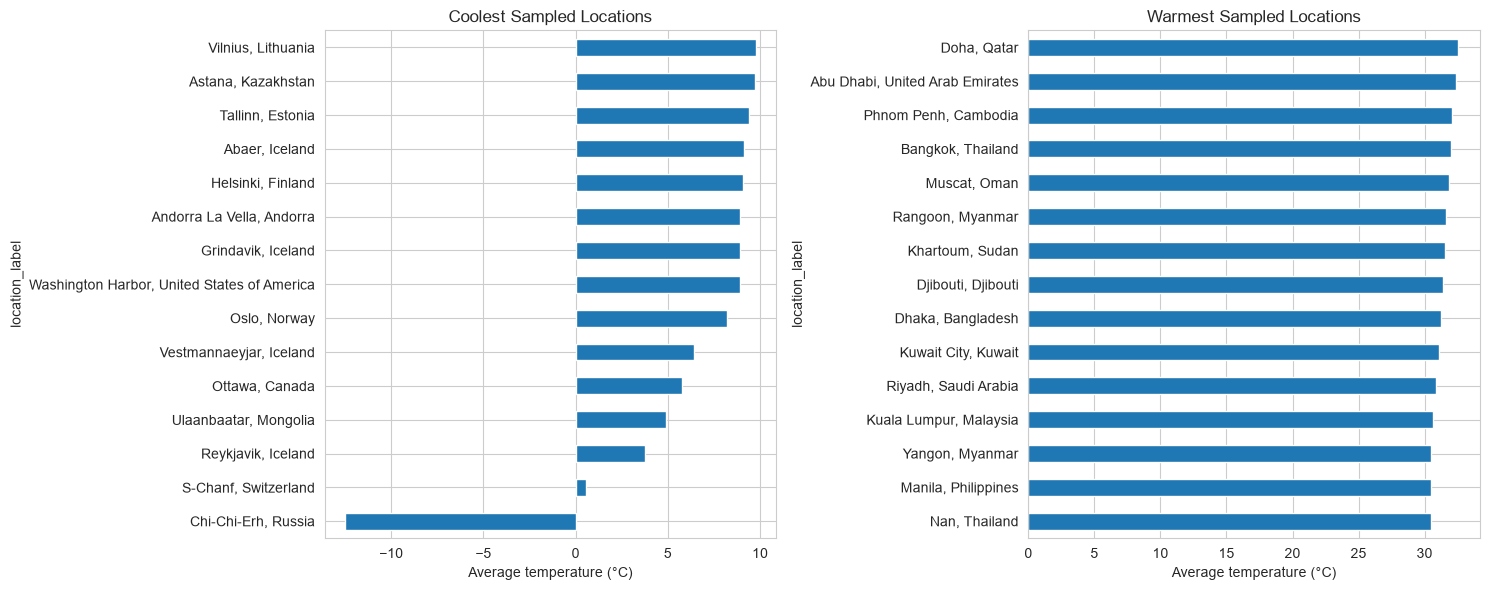

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
location_temperature.head(15).plot(kind="barh", ax=axes[0])
axes[0].set_title("Coolest Sampled Locations")
axes[0].set_xlabel("Average temperature (°C)")

location_temperature.tail(15).plot(kind="barh", ax=axes[1])
axes[1].set_title("Warmest Sampled Locations")
axes[1].set_xlabel("Average temperature (°C)")

plt.tight_layout()
plt.show()

### 6.3 Country-level air quality

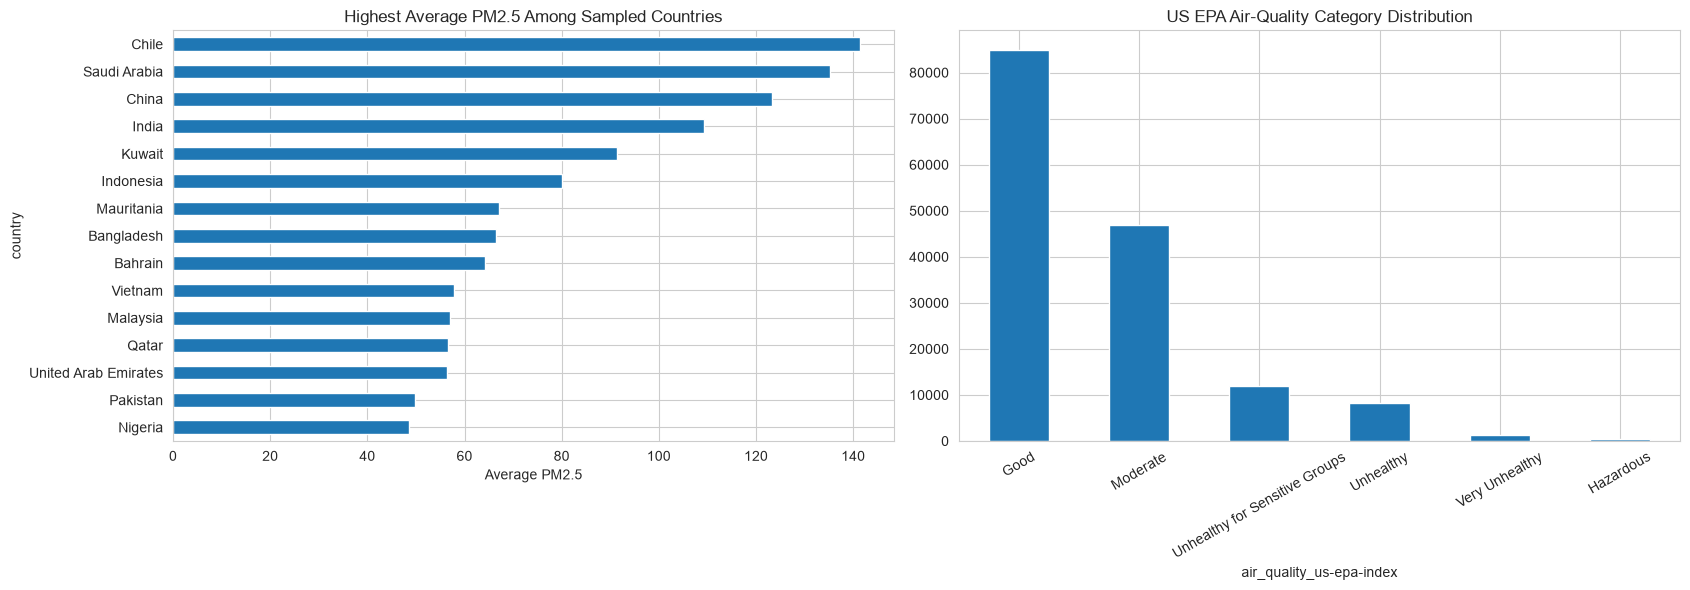

In [32]:
epa_labels = {
    1: "Good",
    2: "Moderate",
    3: "Unhealthy for Sensitive Groups",
    4: "Unhealthy",
    5: "Very Unhealthy",
    6: "Hazardous",
}

country_pm25 = (
    df.groupby("country")["air_quality_PM2.5"]
    .mean()
    .sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

country_pm25.head(15).sort_values().plot(kind="barh", ax=axes[0])
axes[0].set_title("Highest Average PM2.5 Among Sampled Countries")
axes[0].set_xlabel("Average PM2.5")

(
    df["air_quality_us-epa-index"]
    .map(epa_labels)
    .value_counts()
    .reindex(epa_labels.values())
    .plot(kind="bar", ax=axes[1])
)
axes[1].set_title("US EPA Air-Quality Category Distribution")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

### 6.4 Interactive maps

In [33]:
try:
    import plotly.express as px
    PLOTLY_AVAILABLE = True
except ImportError:
    PLOTLY_AVAILABLE = False
    print("Plotly is not installed. Interactive maps will be skipped.")

country_map = (
    df.groupby("country", as_index=False)
    .agg(
        observations=("country", "size"),
        mean_temperature=("temperature_celsius", "mean"),
        mean_pm25=("air_quality_PM2.5", "mean"),
        mean_uv=("uv_index", "mean"),
    )
)

In [34]:
if PLOTLY_AVAILABLE:
    fig_temperature_map = px.choropleth(
        country_map,
        locations="country",
        locationmode="country names",
        color="mean_temperature",
        color_continuous_scale="RdYlBu_r",
        labels={"mean_temperature": "Mean temperature (°C)"},
        title="Average Temperature of Sampled Locations by Country",
    )
    fig_temperature_map.update_geos(
        projection_type="natural earth",
        showcoastlines=True,
        showframe=False,
        showcountries=True,
    )
    fig_temperature_map.update_layout(
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig_temperature_map.show()

In [35]:
if PLOTLY_AVAILABLE:
    fig_pm25_map = px.choropleth(
        country_map,
        locations="country",
        locationmode="country names",
        color="mean_pm25",
        color_continuous_scale="YlOrRd",
        labels={"mean_pm25": "Mean PM2.5"},
        title="Average PM2.5 of Sampled Locations by Country",
    )
    fig_pm25_map.update_geos(
        projection_type="natural earth",
        showcoastlines=True,
        showframe=False,
        showcountries=True,
    )
    fig_pm25_map.update_layout(
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig_pm25_map.show()

## 7. Anomaly Detection

Two complementary approaches are used:

- **IQR analysis** describes extreme values in individual variables.
- **Isolation Forest** identifies unusual multivariate combinations.

The flagged rows are review candidates, not automatically incorrect data.

In [36]:
def iqr_outlier_summary(series: pd.Series, multiplier: float = 1.5) -> dict:
    clean = series.dropna()
    q1 = clean.quantile(0.25)
    q3 = clean.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - multiplier * iqr
    upper = q3 + multiplier * iqr
    count = int(((clean < lower) | (clean > upper)).sum())

    return {
        "lower_bound": lower,
        "upper_bound": upper,
        "outliers": count,
        "outlier_percentage": count / len(clean) * 100,
    }

iqr_rows = []
for column in weather_columns:
    result = iqr_outlier_summary(df[column])
    iqr_rows.append({"variable": column, **result})

iqr_results = (
    pd.DataFrame(iqr_rows)
    .sort_values("outlier_percentage", ascending=False)
)

display(iqr_results.round(2))

,variable,lower_bound,upper_bound,outliers,outlier_percentage
7,visibility_km,10.00,10.00,32366,21.07
6,precip_mm,-0.03,0.05,30763,20.03
3,pressure_mb,998.00,1030.00,4254,2.77
5,gust_kph,-11.00,45.00,4101,2.67
0,temperature_celsius,-1.60,45.60,2982,1.94
1,feels_like_celsius,-4.95,50.65,2911,1.90
4,wind_kph,-11.15,34.85,2567,1.67
9,uv_index,-9.00,15.00,155,0.10
2,humidity,1.00,137.00,0,0.00
8,cloud,-112.50,187.50,0,0.00


In [37]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

anomaly_features = [
    "temperature_celsius",
    "humidity",
    "pressure_mb",
    "wind_kph",
    "precip_mm",
    "uv_index",
]

anomaly_data = df[anomaly_features].dropna()
scaler = StandardScaler()
scaled_anomaly_data = scaler.fit_transform(anomaly_data)

isolation_forest = IsolationForest(
    n_estimators=250,
    contamination=0.02,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
anomaly_labels = isolation_forest.fit_predict(scaled_anomaly_data)
anomaly_scores = isolation_forest.decision_function(scaled_anomaly_data)

df["is_anomaly"] = False
df["anomaly_score"] = np.nan
df.loc[anomaly_data.index, "is_anomaly"] = anomaly_labels == -1
df.loc[anomaly_data.index, "anomaly_score"] = anomaly_scores

print(
    f"Review candidates: {df['is_anomaly'].sum():,} "
    f"({df['is_anomaly'].mean() * 100:.2f}% of observations)"
)

Review candidates: 3,072 (2.00% of observations)


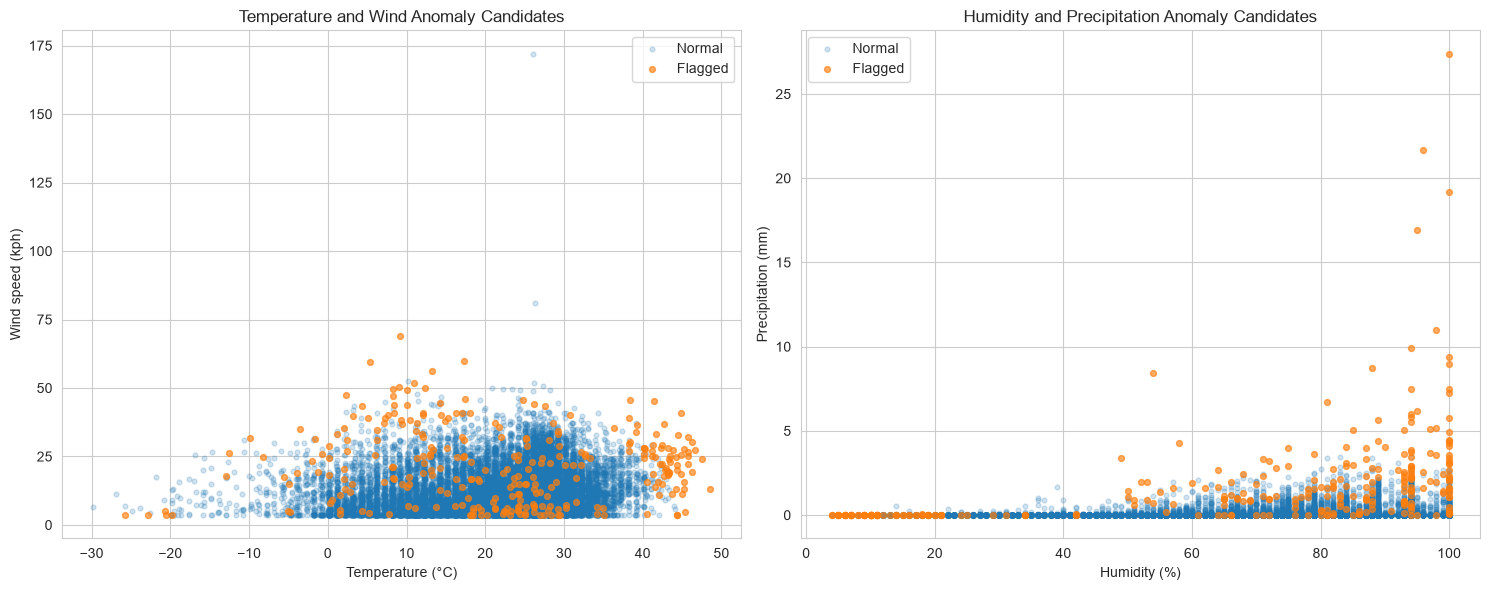

In [38]:
anomaly_sample = anomaly_data.copy()
if len(anomaly_sample) > 15000:
    anomaly_sample = anomaly_sample.sample(
        15000,
        random_state=RANDOM_STATE,
    )

anomaly_sample = anomaly_sample.join(
    df[["is_anomaly"]],
    how="left",
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

normal = anomaly_sample[~anomaly_sample["is_anomaly"]]
flagged = anomaly_sample[anomaly_sample["is_anomaly"]]

axes[0].scatter(
    normal["temperature_celsius"],
    normal["wind_kph"],
    alpha=0.20,
    s=12,
    label="Normal",
)
axes[0].scatter(
    flagged["temperature_celsius"],
    flagged["wind_kph"],
    alpha=0.65,
    s=18,
    label="Flagged",
)
axes[0].set_title("Temperature and Wind Anomaly Candidates")
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Wind speed (kph)")
axes[0].legend()

axes[1].scatter(
    normal["humidity"],
    normal["precip_mm"],
    alpha=0.20,
    s=12,
    label="Normal",
)
axes[1].scatter(
    flagged["humidity"],
    flagged["precip_mm"],
    alpha=0.65,
    s=18,
    label="Flagged",
)
axes[1].set_title("Humidity and Precipitation Anomaly Candidates")
axes[1].set_xlabel("Humidity (%)")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].legend()

plt.tight_layout()
plt.show()

In [39]:
anomalies = df.loc[df["is_anomaly"]].copy()

print("Countries with the most flagged observations")
display(anomalies["country"].value_counts().head(10))

print("Highest-wind review candidates")
display(
    anomalies.nlargest(10, "wind_kph")[
        [
            "country",
            "location_name",
            "last_updated",
            "wind_kph",
            "temperature_celsius",
            "condition_text",
        ]
    ]
)

Countries with the most flagged observations


country
Kuwait          169
Iceland         164
Iraq            139
Saudi Arabia    115
Qatar           106
New Zealand      54
Ethiopia         51
Bahrain          51
Bangladesh       49
Norway           48
Name: count, dtype: int64

Highest-wind review candidates


,country,location_name,last_updated,wind_kph,temperature_celsius,condition_text
7065,Ethiopia,Addis Ababa,2024-06-21 16:30:00,272.2,22.3,Partly cloudy
51288,Iceland,Vestmannaeyjar,2025-02-06 10:15:00,91.1,8.0,Light rain
19654,Norway,Oslo,2024-08-27 14:15:00,78.1,14.4,Light rain
35142,Iceland,Vestmannaeyjar,2024-11-15 09:00:00,76.7,3.3,Light sleet
22578,Norway,Oslo,2024-09-11 14:15:00,76.0,10.2,Partly cloudy
42942,Iceland,Vestmannaeyjar,2024-12-25 10:15:00,76.0,1.2,Blizzard
48559,Iceland,Vestmannaeyjar,2025-01-23 10:30:00,70.2,3.1,Moderate rain
8258,Norway,Oslo,2024-06-27 15:15:00,69.8,16.0,Partly cloudy
12372,China,Beijing,2024-07-19 20:30:00,69.1,27.1,Thundery outbreaks possible
149285,New Zealand,Wellington,2026-06-26 18:00:00,68.8,9.2,Light rain


Because the contamination parameter is set to 2%, the model is instructed to flag approximately 2% of complete rows. These rows may represent genuine extreme weather and should be investigated rather than automatically removed.

## 8. Applied Analyses

The following indices are exploratory decision-support examples. Their formulas and weights are subjective and should not be interpreted as official rankings.

### 8.1 Illustrative livability index

In [40]:
def temperature_comfort(values):
    return np.clip(100 - np.abs(values - 21) * 3.0, 0, 100)

def humidity_comfort(values):
    return np.clip(100 - np.abs(values - 50) * 1.2, 0, 100)

def wind_comfort(values):
    return np.clip(100 - np.abs(values - 10) * 1.5, 0, 100)

def air_quality_comfort(values):
    return np.clip(100 - (values - 1) * 20, 0, 100)

def uv_comfort(values):
    return np.clip(100 - np.maximum(values - 3, 0) * 8, 0, 100)

df["livability_score"] = (
    0.35 * temperature_comfort(df["temperature_celsius"])
    + 0.15 * humidity_comfort(df["humidity"])
    + 0.10 * wind_comfort(df["wind_kph"])
    + 0.25 * air_quality_comfort(df["air_quality_us-epa-index"])
    + 0.15 * uv_comfort(df["uv_index"])
)

In [42]:
livability_summary = (
    df.groupby("country")
    .agg(
        observations=("livability_score", "count"),
        months_covered=("year_month", "nunique"),
        mean_score=("livability_score", "mean"),
        score_std=("livability_score", "std"),
    )
)

eligible_livability = livability_summary[
    (livability_summary["observations"] >= 400)
    & (livability_summary["months_covered"] >= 8)
].copy()

eligible_livability["stability_score"] = (
    100 - eligible_livability["score_std"] * 2
).clip(0, 100)

eligible_livability["adjusted_score"] = (
    0.85 * eligible_livability["mean_score"]
    + 0.15 * eligible_livability["stability_score"]
)

livability_ranking = eligible_livability.sort_values(
    "adjusted_score",
    ascending=False,
)

livability_ranking.head(15).round(2)

,observations,months_covered,mean_score,score_std,stability_score,adjusted_score
country,,,,,,
Costa Rica,767,27,89.52,4.68,90.64,89.69
Honduras,786,27,89.02,3.44,93.13,89.64
Paraguay,738,26,89.62,5.25,89.50,89.61
Fiji Islands,790,27,88.25,2.67,94.66,89.21
Nicaragua,785,27,88.41,3.62,92.75,89.06
Timor-Leste,787,27,87.79,2.91,94.17,88.75
Monaco,787,27,88.36,4.68,90.63,88.70
Belize,786,27,87.63,2.83,94.33,88.64
Brazil,785,27,87.60,3.40,93.20,88.44


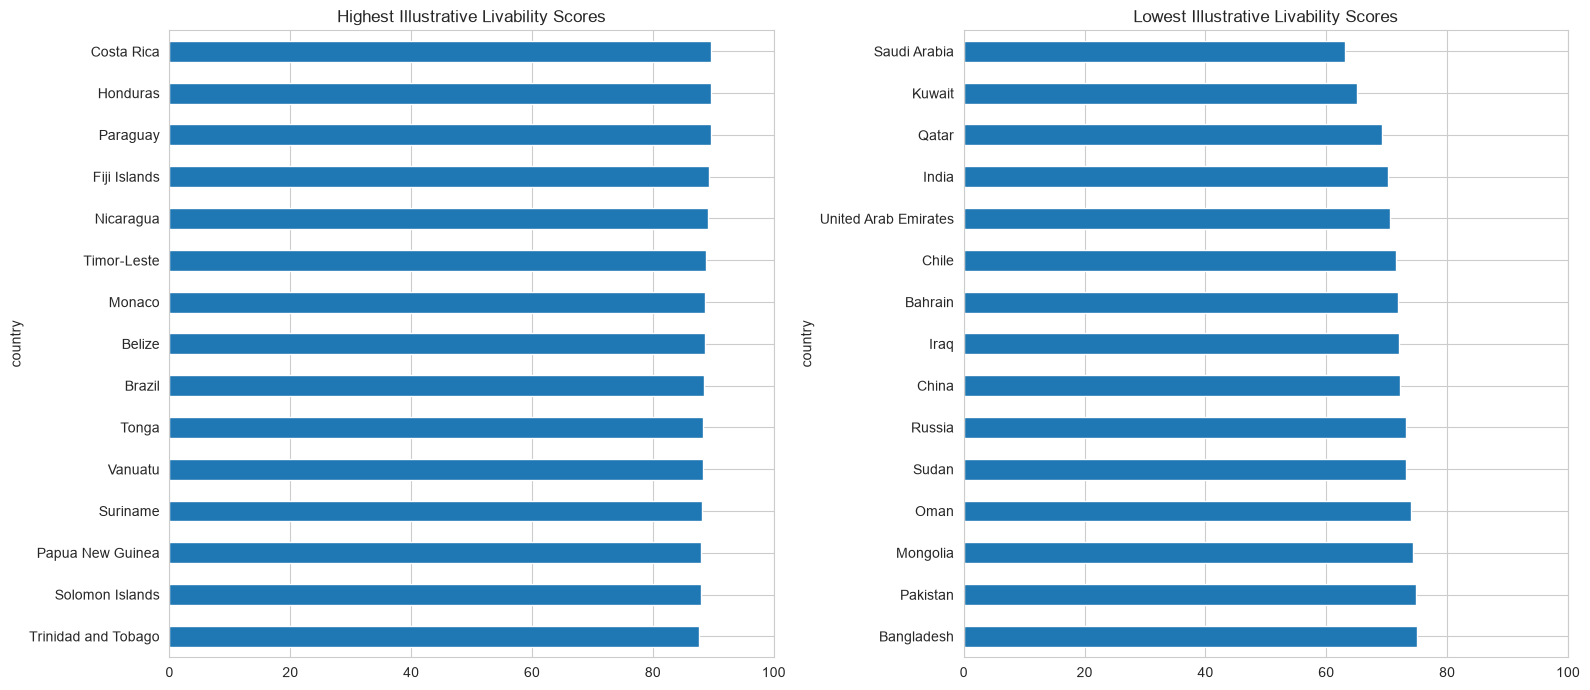

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

livability_ranking.head(15)["adjusted_score"].sort_values().plot(
    kind="barh",
    ax=axes[0],
)
axes[0].set_title("Highest Illustrative Livability Scores")
axes[0].set_xlim(0, 100)

livability_ranking.tail(15)["adjusted_score"].sort_values(ascending=False).plot(
    kind="barh",
    ax=axes[1],
)
axes[1].set_title("Lowest Illustrative Livability Scores")
axes[1].set_xlim(0, 100)

plt.tight_layout()
plt.show()

### 8.2 Illustrative best-time-to-visit score

In [44]:
monthly_visit = (
    df.groupby(["country", "month_name"], observed=False)
    .agg(
        temperature=("temperature_celsius", "mean"),
        humidity=("humidity", "mean"),
        precipitation=("precip_mm", "mean"),
        uv=("uv_index", "mean"),
    )
    .reset_index()
)

visit_temperature = np.clip(
    100 - np.abs(monthly_visit["temperature"] - 23) * 3.0,
    0,
    100,
)
visit_humidity = np.clip(
    100 - np.abs(monthly_visit["humidity"] - 50),
    0,
    100,
)
visit_precipitation = np.clip(
    100 - monthly_visit["precipitation"] * 40,
    0,
    100,
)
visit_uv = np.clip(
    100 - np.maximum(monthly_visit["uv"] - 3, 0) * 8,
    0,
    100,
)

monthly_visit["visit_score"] = (
    0.40 * visit_temperature
    + 0.20 * visit_humidity
    + 0.25 * visit_precipitation
    + 0.15 * visit_uv
)

best_month_by_country = monthly_visit.loc[
    monthly_visit.groupby("country")["visit_score"].idxmax(),
    [
        "country",
        "month_name",
        "visit_score",
        "temperature",
        "precipitation",
    ],
].sort_values("visit_score", ascending=False)

display(best_month_by_country.head(20).round(2))

,country,month_name,visit_score,temperature,precipitation
827,Guinea-Bissau,December,99.66,23.21,0.00
1544,Paraguay,September,99.18,22.88,0.00
731,Gambia,December,99.16,22.87,0.00
1222,Mali,November,99.16,23.48,0.00
1252,Mauritania,May,98.25,23.23,0.00
777,Greece,October,98.21,22.22,0.07
1090,Lebanon,November,98.18,22.81,0.07
1607,Qatar,December,98.09,23.85,0.00
1727,Senegal,December,98.06,22.93,0.00
2088,United Arab Emirates,January,98.01,22.65,0.00


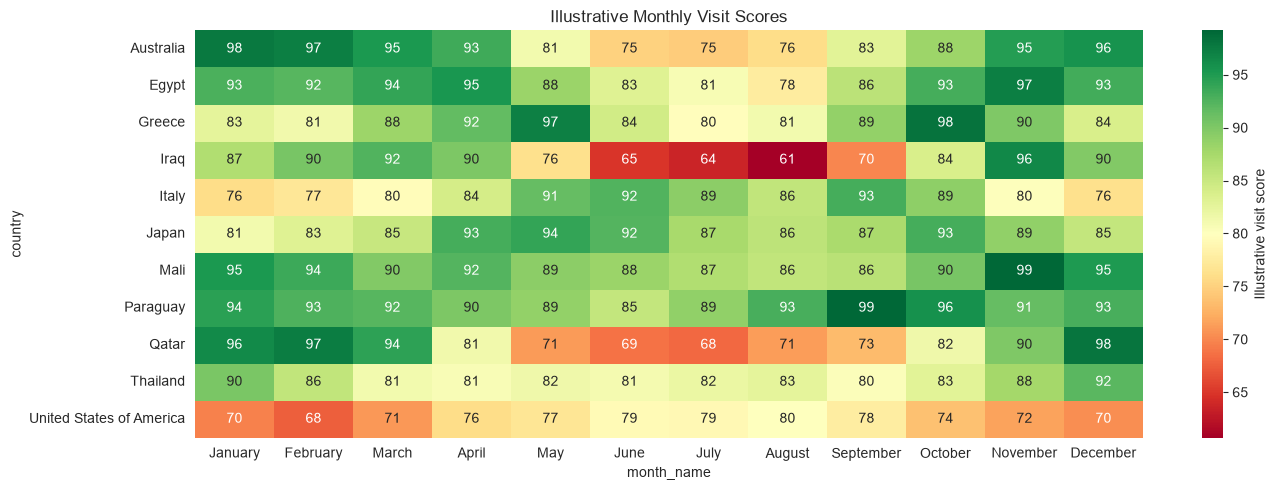

In [47]:
example_countries = [
    "Thailand",
    "Italy",
    "Japan",
    "Egypt",
    "Australia",
    "United States of America",
    "Qatar",
    "Greece",
    "Paraguay",
    "Iraq",
    "Mali"
]
example_countries = [
    country
    for country in example_countries
    if country in monthly_visit["country"].unique()
]

visit_heatmap = (
    monthly_visit[monthly_visit["country"].isin(example_countries)]
    .pivot(index="country", columns="month_name", values="visit_score")
    .reindex(columns=month_order)
)

plt.figure(figsize=(14, 5))
sns.heatmap(
    visit_heatmap,
    annot=True,
    fmt=".0f",
    cmap="RdYlGn",
    cbar_kws={"label": "Illustrative visit score"},
)
plt.title("Illustrative Monthly Visit Scores")
plt.tight_layout()
plt.show()

### 8.3 Wind-resource screening proxy

In [48]:
df["wind_ms"] = df["wind_kph"] / 3.6

wind_summary = (
    df.groupby("country")
    .agg(
        average_wind_kph=("wind_kph", "mean"),
        average_gust_kph=("gust_kph", "mean"),
        percent_above_20_kph=("wind_kph", lambda values: (values > 20).mean() * 100),
        mean_cubed_wind_speed=("wind_ms", lambda values: (values ** 3).mean()),
    )
    .sort_values("average_wind_kph", ascending=False)
)

display(wind_summary.head(15).round(2))

,average_wind_kph,average_gust_kph,percent_above_20_kph,mean_cubed_wind_speed
country,,,,
Somalia,26.92,32.45,83.40,489.66
Saint Vincent and the Grenadines,26.64,36.45,85.15,481.01
Saint Kitts and Nevis,26.28,38.25,78.83,723.34
Antigua and Barbuda,25.03,36.50,74.46,436.63
Barbados,24.87,35.04,76.93,410.76
New Zealand,24.82,37.74,60.38,625.51
Iceland,23.36,34.59,49.56,670.80
Tonga,23.28,33.61,60.48,437.60
Azerbaijan,22.97,30.08,53.80,511.56


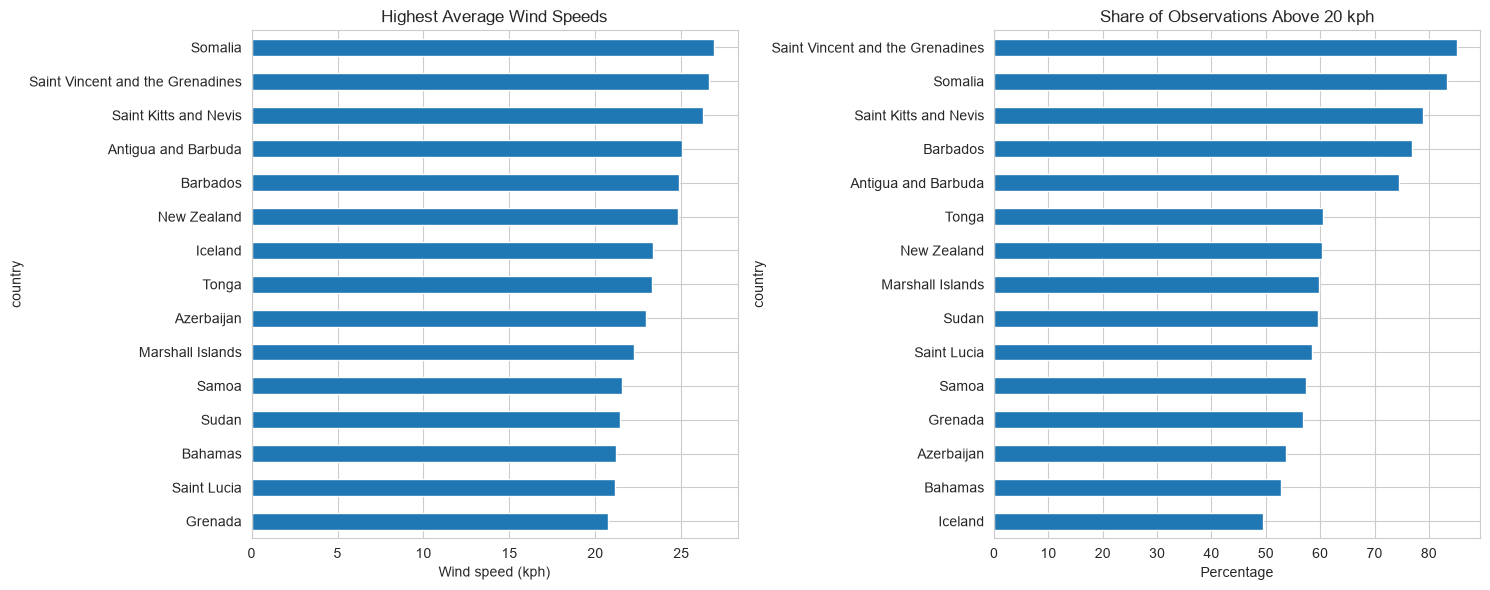

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

wind_summary.head(15)["average_wind_kph"].sort_values().plot(
    kind="barh",
    ax=axes[0],
)
axes[0].set_title("Highest Average Wind Speeds")
axes[0].set_xlabel("Wind speed (kph)")

wind_summary.head(15)["percent_above_20_kph"].sort_values().plot(
    kind="barh",
    ax=axes[1],
)
axes[1].set_title("Share of Observations Above 20 kph")
axes[1].set_xlabel("Percentage")

plt.tight_layout()
plt.show()

This is a high-level screening proxy only. Real wind-energy assessment requires hub-height measurements, terrain information, air density, turbine characteristics, and much longer site-specific records.

### 8.4 UV exposure patterns

In [50]:
uv_country = (
    df.groupby("country")["uv_index"]
    .agg(["mean", "max"])
    .sort_values("mean", ascending=False)
)

display(uv_country.head(15).round(2))
display(
    df.nlargest(10, "uv_index")[
        ["country", "location_name", "uv_index", "last_updated"]
    ]
)

,mean,max
country,,
Seychelles Islands,9.57,14.8
Somalia,8.58,14.7
Yemen,8.34,15.4
Madagascar,8.23,16.0
Tanzania,8.15,15.6
Kenya,8.15,16.0
Maldives,8.07,13.9
Comoros,8.06,14.7
Mauritius,7.94,14.2


,country,location_name,uv_index,last_updated
52185,Zambia,Lusaka,16.3,2025-02-10 12:30:00
47280,South Africa,Pretoria,16.1,2025-01-16 12:00:00
45306,Madagascar,Antananarivo,16.0,2025-01-06 12:45:00
46533,Zimbabwe,Harare,16.0,2025-01-12 12:30:00
47118,Zimbabwe,Harare,16.0,2025-01-15 12:30:00
53652,Malawi,Lilongwe,16.0,2025-02-18 12:00:00
53743,Zambia,Lusaka,16.0,2025-02-18 12:15:00
58282,Ethiopia,Addis Ababa,16.0,2025-03-14 12:45:00
59873,Kenya,Nairobi,16.0,2025-03-22 12:30:00
46653,Namibia,Windhoek,15.9,2025-01-13 13:30:00


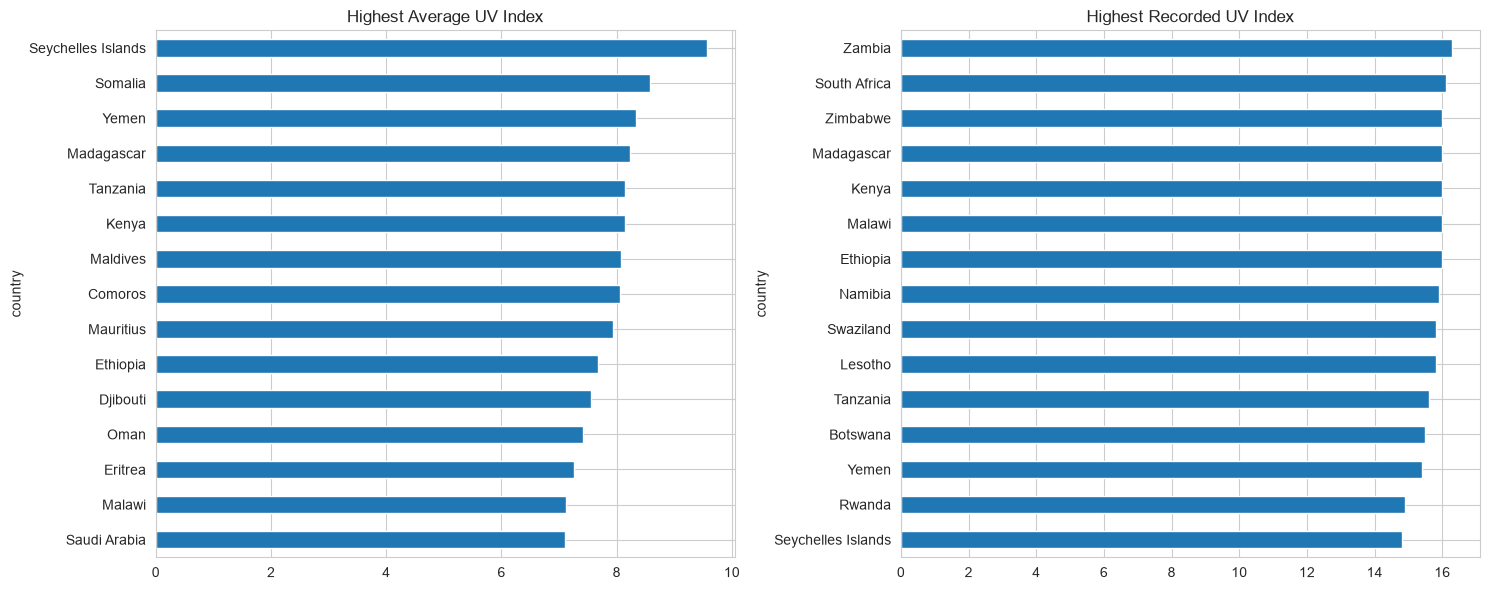

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

uv_country.head(15)["mean"].sort_values().plot(
    kind="barh",
    ax=axes[0],
)
axes[0].set_title("Highest Average UV Index")

uv_country.sort_values("max", ascending=False).head(15)["max"].sort_values().plot(
    kind="barh",
    ax=axes[1],
)
axes[1].set_title("Highest Recorded UV Index")

plt.tight_layout()
plt.show()

In [52]:
if PLOTLY_AVAILABLE:
    fig_uv_map = px.choropleth(
        country_map,
        locations="country",
        locationmode="country names",
        color="mean_uv",
        color_continuous_scale="Plasma",
        labels={"mean_uv": "Mean UV index"},
        title="Average UV Index of Sampled Locations by Country",
    )
    fig_uv_map.update_geos(
        projection_type="natural earth",
        showcoastlines=True,
        showframe=False,
        showcountries=True,
    )
    fig_uv_map.update_layout(
        margin=dict(l=0, r=0, t=50, b=0)
    )
    fig_uv_map.show()

## 9. Appendix: Recorded Update-Time Patterns

The following analysis groups observations by the hour stored in `last_updated`. Because locations are not observed on a consistent hourly schedule, these plots describe **recorded update-hour patterns**, not reliable local diurnal or rush-hour effects.

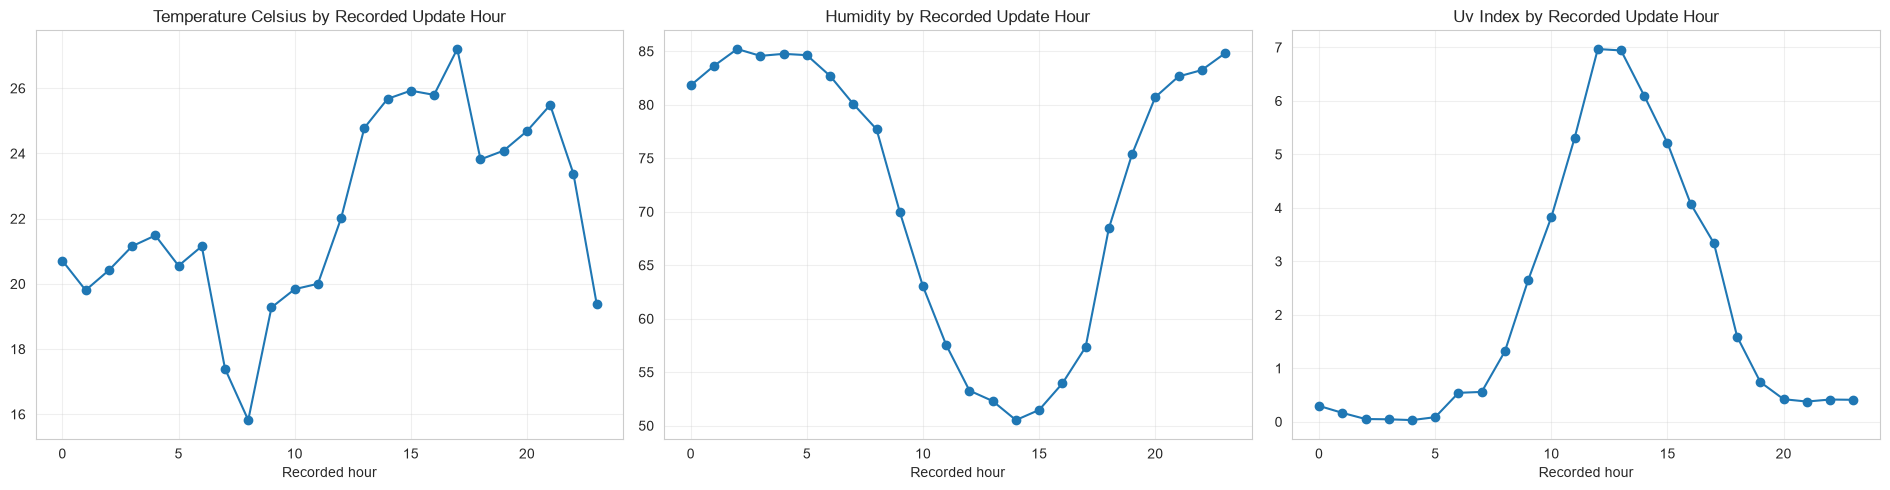

In [53]:
recorded_hour_weather = (
    df.groupby("recorded_hour")[
        ["temperature_celsius", "humidity", "uv_index"]
    ]
    .mean()
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

for ax, column in zip(axes, recorded_hour_weather.columns):
    recorded_hour_weather[column].plot(ax=ax, marker="o")
    ax.set_title(
        column.replace("_", " ").title()
        + " by Recorded Update Hour"
    )
    ax.set_xlabel("Recorded hour")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

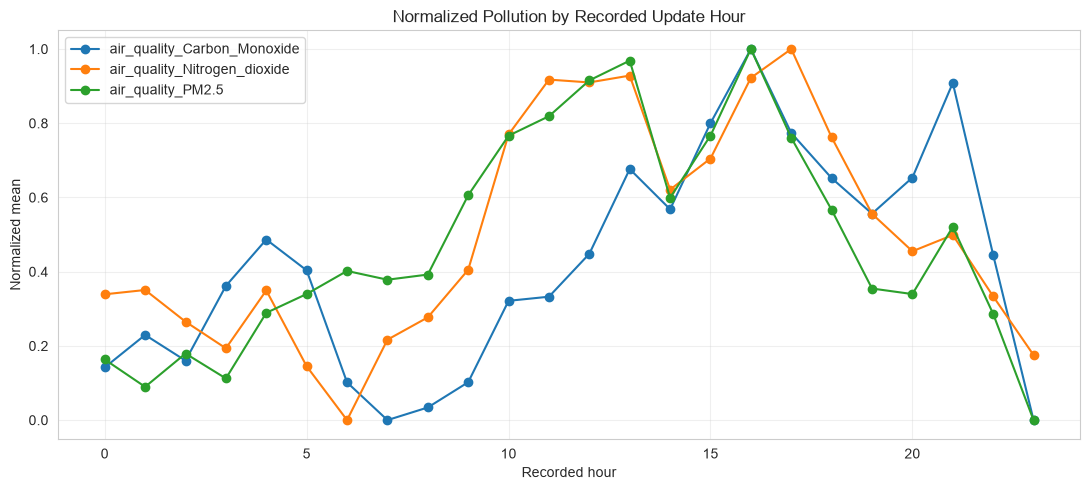

In [54]:
recorded_hour_pollution = (
    df.groupby("recorded_hour")[
        [
            "air_quality_Carbon_Monoxide",
            "air_quality_Nitrogen_dioxide",
            "air_quality_PM2.5",
        ]
    ]
    .mean()
)

normalized_pollution = (
    recorded_hour_pollution - recorded_hour_pollution.min()
) / (
    recorded_hour_pollution.max() - recorded_hour_pollution.min()
)

fig, ax = plt.subplots(figsize=(11, 5))
normalized_pollution.plot(ax=ax, marker="o")
ax.set_title("Normalized Pollution by Recorded Update Hour")
ax.set_xlabel("Recorded hour")
ax.set_ylabel("Normalized mean")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 10. Limitations and Key Conclusions

### Limitations

- The dataset covers a little over two years, so it supports seasonal and short-term comparisons rather than long-term climate-change conclusions.
- Country summaries represent sampled locations, not full national spatial coverage.
- Location coverage varies, and some countries have more sampled locations than others.
- Recorded update times do not form a consistent hourly panel.
- Correlations do not establish causal relationships.
- The livability and travel scores are illustrative and depend on subjective formulas.
- Isolation Forest candidates may be genuine extreme weather, not data errors.

### Key conclusions

- Temperature, humidity, cloud, visibility, precipitation, and wind show strong, physically plausible relationships.
- Global monthly averages show a visible seasonal cycle, though both hemispheres and uneven sampling are combined.
- Air pollutants are highly right-skewed and several pollutants tend to rise together.
- Geographic patterns are clear: temperatures generally decrease with distance from the equator.
- Multivariate anomaly detection identifies a manageable set of unusual observations for investigation.
- Applied indices can turn weather variables into decision-support examples, provided their assumptions are stated clearly.